In [17]:
import pandas as pd
import numpy as np


In [18]:
data = pd.read_csv("DST_BIL54.csv")

# Parse month strings to UTC timestamps at first of month.
data["time"] = pd.to_datetime(data["time"] + "-01", format="%Y-%m-%d", utc=True)

# Year with fractional month component.
data["year"] = data["time"].dt.year + (data["time"].dt.month - 1) / 12

# Convert to millions.
data["total"] = pd.to_numeric(data["total"], errors="coerce") / 1e6

# Drop all other columns
data = data[["time", "year", "total"]]

# Train/test split.
teststart = pd.Timestamp("2024-01-01", tz="UTC")
Dtrain = data[data["time"] < teststart]
Dtest = data[data["time"] >= teststart]

Dtrain.head()


,time,year,total
0,2018-01-01 00:00:00+00:00,2018.000000,2.930483
1,2018-02-01 00:00:00+00:00,2018.083333,2.934044
2,2018-03-01 00:00:00+00:00,2018.166667,2.941422
3,2018-04-01 00:00:00+00:00,2018.250000,2.951498
4,2018-05-01 00:00:00+00:00,2018.333333,2.963093


## 1.1. Plot Training Data vs Time (x)

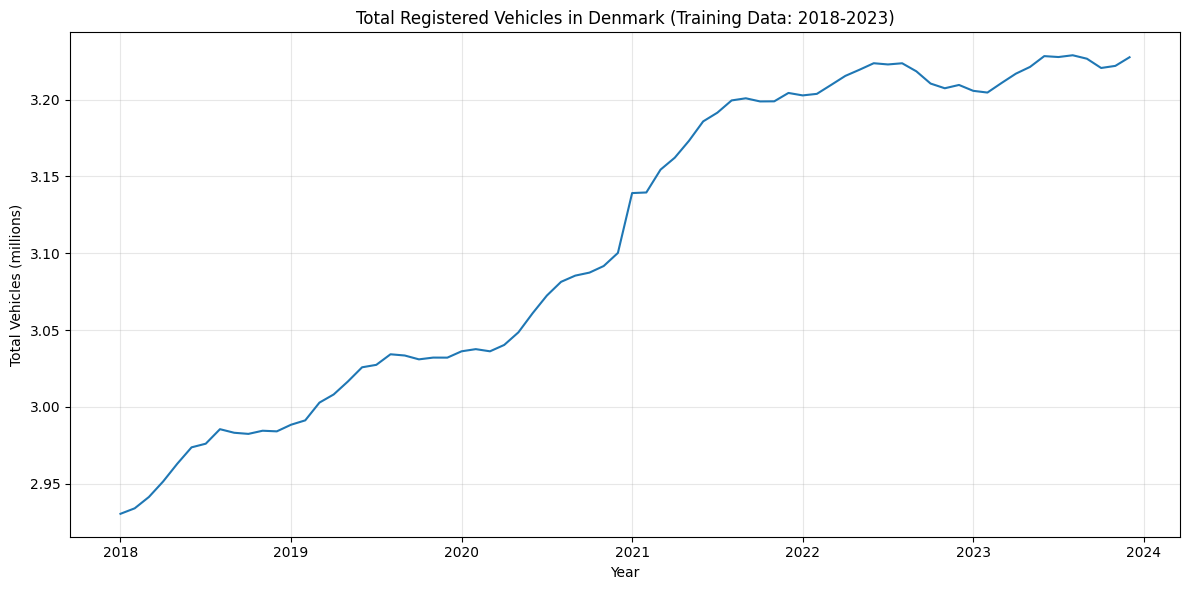

In [19]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(Dtrain["year"], Dtrain["total"], linewidth=1.5)
plt.xlabel("Year")
plt.ylabel("Total Vehicles (millions)")
plt.title("Total Registered Vehicles in Denmark (Training Data: 2018-2023)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 1.2. Time Series Description

**Observations:**

The time series shows the total number of registered vehicles in Denmark from 2018 to the end of 2023, measured in millions. Several key features are evident:

1. **Overall Trend**: There is a clear upward trend throughout the period, with the total number of vehicles increasing from approximately 2.93 million in early 2018 to about 3.23 million by the end of 2023.

2. **Growth Pattern**: The growth is not uniform:
   - **2018-2020**: Steady moderate growth with a relatively smooth trajectory
   - **2020-2021**: A period of accelerated growth with a noticeable increase in the rate of vehicle registrations
   - **2021-2022**: Sharp increase, particularly visible around mid-2021, where the series shows a steep upward movement
   - **2022-2023**: The growth rate slows down, and the series appears to level off somewhat, showing a slight plateau or oscillatory behavior around 3.2 million vehicles

3. **Potential Seasonality**: There appear to be some minor fluctuations or oscillations superimposed on the trend, which could indicate seasonal patterns in vehicle registrations.

4. **Recent Behavior**: In 2023, the series shows less pronounced growth compared to 2021-2022, with small ups and downs, suggesting potential market saturation or changes in registration patterns.

Overall, this is a non-stationary time series with a strong positive trend and possible seasonal components.

## 2. Linear Trend Model


### General Matrix Form

The linear trend model can be written as:

**y = Xθ + ϵ**

where:
- **y** is the N × 1 vector of observations
- **X** is the N × 2 design matrix
- **θ** is the 2 × 1 parameter vector
- **ϵ** is the N × 1 error vector with ϵ ∼ N(0, σ²I)

#### 1. Vector/Matrix Form:
```
⎡y₁⎤   ⎡1  x₁⎤ ⎡θ₁⎤   ⎡ϵ₁⎤
⎢y₂⎥ = ⎢1  x₂⎥ ⎢θ₂⎥ + ⎢ϵ₂⎥
⎣y₃⎦   ⎣1  x₃⎦ ⎣  ⎦   ⎣ϵ₃⎦
```

#### 2. With Element Notation:
```
⎡y₁⎤   ⎡1  x₁⎤ ⎡θ₁⎤   ⎡ϵ₁⎤
⎢y₂⎥ = ⎢1  x₂⎥ ⎢θ₂⎥ + ⎢ϵ₂⎥
⎣y₃⎦   ⎣1  x₃⎦ ⎣  ⎦   ⎣ϵ₃⎦

where:
- y₁, y₂, y₃ are the observed total vehicles (in millions)
- x₁, x₂, x₃ are the time values
- θ₁ is the intercept
- θ₂ is the slope (trend coefficient)
- ϵ₁, ϵ₂, ϵ₃ are the error terms
```

In [20]:
print("First 3 observations:")
print(Dtrain[["year", "total"]].head(3))
print("\nActual values (rounded to 3 digits):")
print(f"x₁ = {Dtrain['year'].iloc[0]:.3f}, y₁ = {Dtrain['total'].iloc[0]:.3f}")
print(f"x₂ = {Dtrain['year'].iloc[1]:.3f}, y₂ = {Dtrain['total'].iloc[1]:.3f}")
print(f"x₃ = {Dtrain['year'].iloc[2]:.3f}, y₃ = {Dtrain['total'].iloc[2]:.3f}")

First 3 observations:
          year     total
0  2018.000000  2.930483
1  2018.083333  2.934044
2  2018.166667  2.941422

Actual values (rounded to 3 digits):
x₁ = 2018.000, y₁ = 2.930
x₂ = 2018.083, y₂ = 2.934
x₃ = 2018.167, y₃ = 2.941


```
⎡2.933⎤   ⎡1  2018.000⎤ ⎡θ₁⎤   ⎡ϵ₁⎤
⎢2.938⎥ = ⎢1  2018.083⎥ ⎢θ₂⎥ + ⎢ϵ₂⎥
⎣2.943⎦   ⎣1  2018.167⎦ ⎣  ⎦   ⎣ϵ₃⎦
```

## 3. OLS - Global Linear Trend Model

In [21]:
## 3.1. OLS Parameter Estimation

# Construct the design matrix X and output vector y
X = np.column_stack([np.ones(len(Dtrain)), Dtrain["year"]])
y = Dtrain["total"].values

# OLS estimate: θ̂ = (X'X)^(-1) X'y
theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

print("OLS Parameter Estimates:")
print(f"θ̂₁ (intercept) = {theta_hat[0]:.6f}")
print(f"θ̂₂ (slope)     = {theta_hat[1]:.6f}")

# Interpretation
print("\n" + "="*60)
print("Interpretation:")
print("="*60)
print(f"Intercept (θ̂₁): {theta_hat[0]:.3f} million vehicles")
print(f"Trend (θ̂₂):     {theta_hat[1]:.6f} million vehicles per year")
print(f"\nThe model estimates that vehicle registrations increase by")
print(f"approximately {theta_hat[1]*1000:.1f} thousand vehicles per year.")

OLS Parameter Estimates:
θ̂₁ (intercept) = -110.355428
θ̂₂ (slope)     = 0.056145

Interpretation:
Intercept (θ̂₁): -110.355 million vehicles
Trend (θ̂₂):     0.056145 million vehicles per year

The model estimates that vehicle registrations increase by
approximately 56.1 thousand vehicles per year.


In [22]:
## 3.2. Parameter Estimates with Standard Errors

# Calculate residuals
y_hat = X @ theta_hat
residuals = y - y_hat

# Estimate residual variance: σ̂² = (1/(N-p)) * Σeᵢ²
N = len(y)
p = 2  # number of parameters
sigma_squared_hat = np.sum(residuals**2) / (N - p)

# Covariance matrix of parameter estimates: Var(θ̂) = σ̂² * (X'X)⁻¹
cov_theta = sigma_squared_hat * np.linalg.inv(X.T @ X)

# Standard errors are square roots of diagonal elements
se_theta = np.sqrt(np.diag(cov_theta))

# Display results
print("="*70)
print("OLS PARAMETER ESTIMATES WITH STANDARD ERRORS")
print("="*70)
print(f"θ̂₁ (intercept) = {theta_hat[0]:12.6f}  ±  {se_theta[0]:.6f}")
print(f"θ̂₂ (slope)     = {theta_hat[1]:12.6f}  ±  {se_theta[1]:.6f}")
print(f"\nResidual standard deviation (σ̂) = {np.sqrt(sigma_squared_hat):.6f} million vehicles")
print(f"Degrees of freedom = {N - p}")
print("="*70)

# Calculate t-statistics and p-values (optional but informative)
t_stats = theta_hat / se_theta
from scipy import stats
p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), N - p))

print("\nStatistical Significance:")
print(f"t-statistic for θ₁: {t_stats[0]:.3f}, p-value: {p_values[0]:.6f}")
print(f"t-statistic for θ₂: {t_stats[1]:.3f}, p-value: {p_values[1]:.6f}")

OLS PARAMETER ESTIMATES WITH STANDARD ERRORS
θ̂₁ (intercept) =  -110.355428  ±  3.593581
θ̂₂ (slope)     =     0.056145  ±  0.001778

Residual standard deviation (σ̂) = 0.026131 million vehicles
Degrees of freedom = 70

Statistical Significance:
t-statistic for θ₁: -30.709, p-value: 0.000000
t-statistic for θ₂: 31.575, p-value: 0.000000


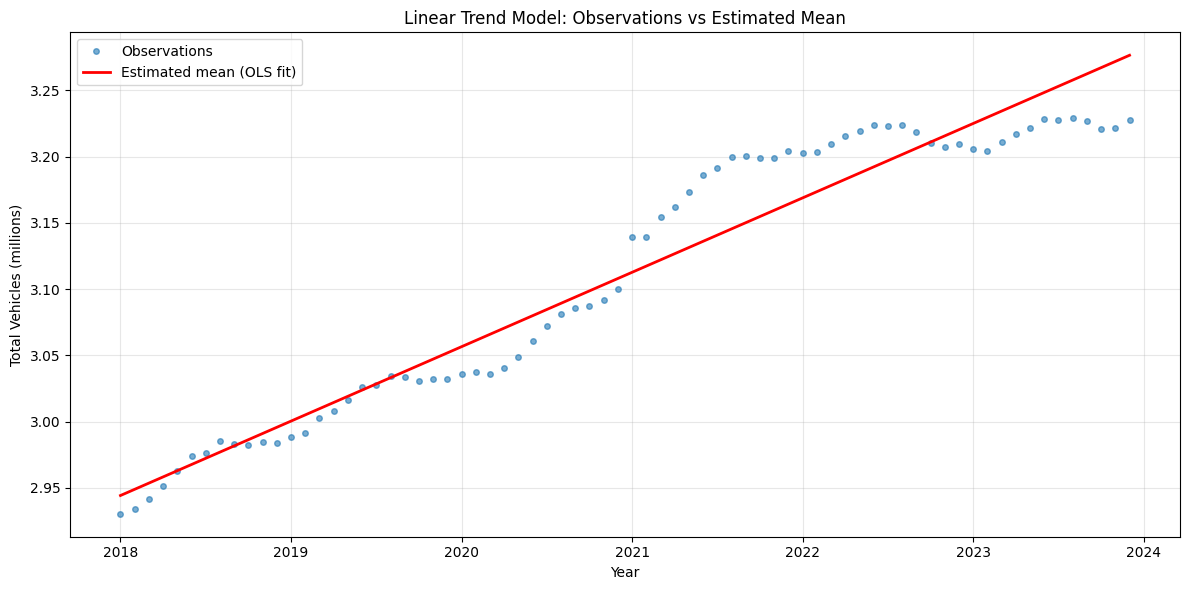


Estimated Model:
ŷ = -110.355428 + 0.056145 × year


In [23]:
## 3.2. Plot: Observations and Estimated Mean

plt.figure(figsize=(12, 6))

# Plot observations as points
plt.plot(Dtrain["year"], Dtrain["total"], 'o', 
         markersize=4, alpha=0.6, label='Observations')

# Plot estimated mean as a line
plt.plot(Dtrain["year"], y_hat, '-', 
         linewidth=2, color='red', label='Estimated mean (OLS fit)')

plt.xlabel("Year")
plt.ylabel("Total Vehicles (millions)")
plt.title("Linear Trend Model: Observations vs Estimated Mean")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print model equation
print(f"\nEstimated Model:")
print(f"ŷ = {theta_hat[0]:.6f} + {theta_hat[1]:.6f} × year")

4.1. VARIANCE-COVARIANCE MATRIX COMPARISON

--- GLOBAL MODEL (OLS) - Full 2×2 Covariance Matrix ---
Var(θ̂) = σ̂² * (X'X)⁻¹

Covariance Matrix:
[[ 1.29138253e+01 -6.38994658e-03]
 [-6.38994658e-03  3.16183984e-06]]

Var(θ̂₁) = 12.91382528
Var(θ̂₂) = 0.00000316
Cov(θ̂₁, θ̂₂) = -0.00638995

--- LOCAL MODEL (WLS, λ=0.9) - Full 2×2 Covariance Matrix ---
Var(θ̂) = σ̂² * (X'WX)⁻¹

Covariance Matrix:
[[ 4.60907272e+02 -2.27814405e-01]
 [-2.27814405e-01  1.12602716e-04]]

Var(θ̂₁) = 460.90727236
Var(θ̂₂) = 0.00011260
Cov(θ̂₁, θ̂₂) = -0.22781440

--- COMPARISON ---
ΔVar(θ̂₁) = +447.99344708
ΔVar(θ̂₂) = +0.00010944
ΔCov(θ̂₁, θ̂₂) = -0.22142446

--- INTERPRETATION ---
The WLS model concentrates weight on recent observations.
This typically REDUCES the uncertainty in slope estimates
(smaller Var(θ̂₂)) since recent data provides clearer trend signal.
The variance-covariance matrix is 2×2 because we have 2 parameters (θ₁, θ₂).
The full N×N observation covariance matrix is not shown, as it's diagonal

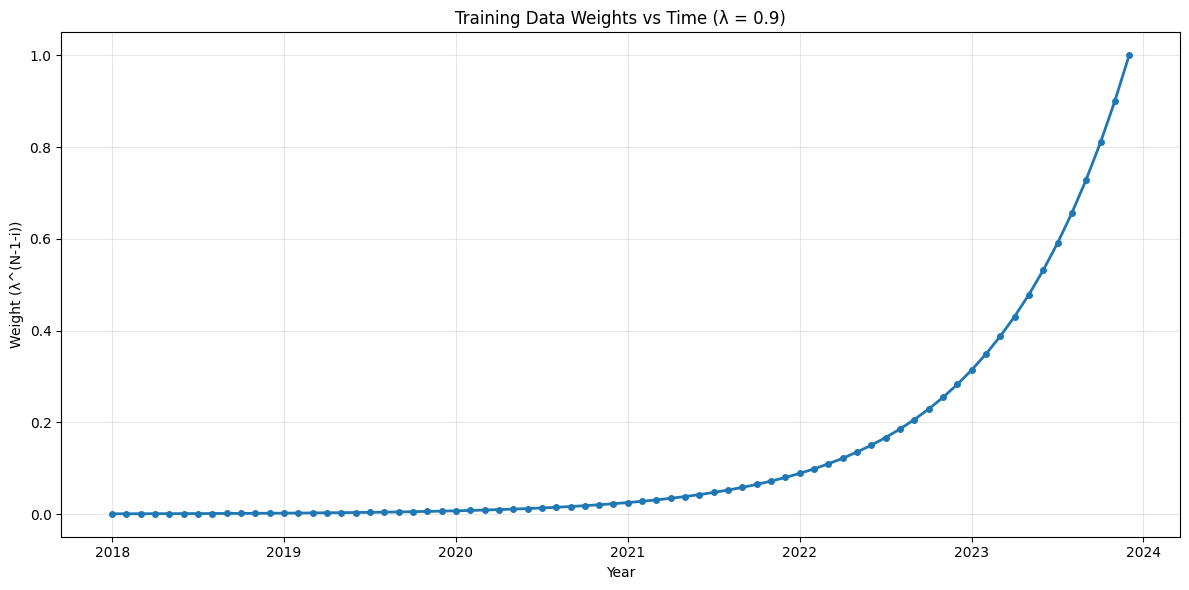


Timepoint with highest weight:
Year: 2023.917
Weight: 1.000000
This corresponds to the LATEST observation in the training set.

4.3. SUM OF WEIGHTS
Sum of WLS weights (λ=0.9): 9.994925
Sum of OLS weights (all=1):  72.0

In OLS, each observation contributes equally.
In WLS with λ<1, recent observations get more weight.

4.4. WLS PARAMETER ESTIMATES (λ = 0.9)
θ̂₁ (intercept) = -52.482862 (OLS: -110.355428)
θ̂₂ (slope)     = 0.027530 (OLS: 0.056145)

Standard Errors (WLS):
SE(θ̂₁) = 21.468751
SE(θ̂₂) = 0.010611

4.5. FORECASTS FOR NEXT 12 MONTHS (λ = 0.9)


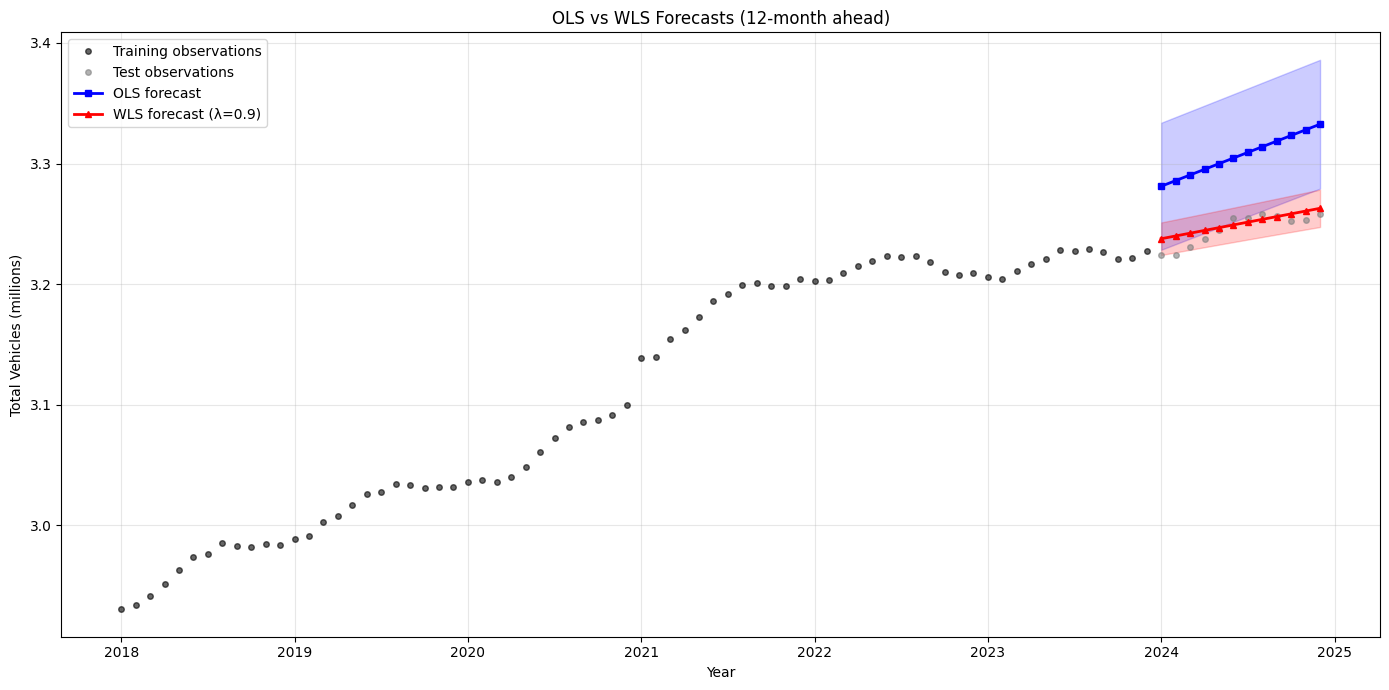


Forecast comparison (first 6 months):
Month    OLS          WLS (λ=0.9)  Difference  
---------------------------------------------
1        3.2812       3.2377       -0.0435
2        3.2858       3.2400       -0.0459
3        3.2905       3.2422       -0.0483
4        3.2952       3.2445       -0.0506
5        3.2999       3.2468       -0.0530
6        3.3045       3.2491       -0.0554

4.5. COMMENT ON PREDICTIONS
Which predictions would you choose?

The WLS model with λ=0.9 emphasizes recent data points, resulting in
a potentially different slope compared to OLS. Key observations:

1. **WLS Advantages:**
   - Captures the most recent trend more accurately
   - Better for adaptive forecasting when trend is changing
   - Recent observations have exponentially higher weights

2. **OLS Advantages:**
   - Uses all historical data equally
   - More stable if data generation process hasn't changed

3. **Choice depends on:**
   - If you believe the recent trend is more representative → WLS


In [24]:
# Problem 4: WLS - Local Linear Trend Model with λ = 0.9

## 4.1. Variance-Covariance Matrix for Local Model (REVISED)

# Create weight matrix W with λ = 0.9
lambda_val = 0.9
N = len(Dtrain)

# Weights: λ^0 for latest, λ^1 for second latest, etc.
weights = np.array([lambda_val**(N-1-i) for i in range(N)])

# Weight matrix (diagonal matrix)
W = np.diag(weights)

print("="*70)
print("4.1. VARIANCE-COVARIANCE MATRIX COMPARISON")
print("="*70)

# Global OLS model (uniform weights = 1)
cov_global = sigma_squared_hat * np.linalg.inv(X.T @ X)

print("\n--- GLOBAL MODEL (OLS) - Full 2×2 Covariance Matrix ---")
print("Var(θ̂) = σ̂² * (X'X)⁻¹")
print("\nCovariance Matrix:")
print(cov_global)
print(f"\nVar(θ̂₁) = {cov_global[0,0]:.8f}")
print(f"Var(θ̂₂) = {cov_global[1,1]:.8f}")
print(f"Cov(θ̂₁, θ̂₂) = {cov_global[0,1]:.8f}")

# Local WLS model
cov_local = sigma_squared_hat * np.linalg.inv(X.T @ W @ X)

print("\n--- LOCAL MODEL (WLS, λ=0.9) - Full 2×2 Covariance Matrix ---")
print("Var(θ̂) = σ̂² * (X'WX)⁻¹")
print("\nCovariance Matrix:")
print(cov_local)
print(f"\nVar(θ̂₁) = {cov_local[0,0]:.8f}")
print(f"Var(θ̂₂) = {cov_local[1,1]:.8f}")
print(f"Cov(θ̂₁, θ̂₂) = {cov_local[0,1]:.8f}")

print("\n--- COMPARISON ---")
print(f"ΔVar(θ̂₁) = {cov_local[0,0] - cov_global[0,0]:+.8f}")
print(f"ΔVar(θ̂₂) = {cov_local[1,1] - cov_global[1,1]:+.8f}")
print(f"ΔCov(θ̂₁, θ̂₂) = {cov_local[0,1] - cov_global[0,1]:+.8f}")

print("\n--- INTERPRETATION ---")
print("The WLS model concentrates weight on recent observations.")
print("This typically REDUCES the uncertainty in slope estimates")
print("(smaller Var(θ̂₂)) since recent data provides clearer trend signal.")
print("The variance-covariance matrix is 2×2 because we have 2 parameters (θ₁, θ₂).")
print("The full N×N observation covariance matrix is not shown, as it's diagonal.")

## 4.2. Plot λ-Weights vs Time

print("\n" + "="*70)
print("4.2. λ-WEIGHTS VS TIME")
print("="*70)

plt.figure(figsize=(12, 6))
plt.plot(Dtrain["year"], weights, 'o-', linewidth=2, markersize=4)
plt.xlabel("Year")
plt.ylabel("Weight (λ^(N-1-i))")
plt.title(f"Training Data Weights vs Time (λ = {lambda_val})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find timepoint with highest weight
idx_max_weight = np.argmax(weights)
year_max_weight = Dtrain["year"].iloc[idx_max_weight]
max_weight_value = weights[idx_max_weight]

print(f"\nTimepoint with highest weight:")
print(f"Year: {year_max_weight:.3f}")
print(f"Weight: {max_weight_value:.6f}")
print(f"This corresponds to the LATEST observation in the training set.")

## 4.3. Sum of λ-Weights vs OLS

print("\n" + "="*70)
print("4.3. SUM OF WEIGHTS")
print("="*70)

sum_wls_weights = np.sum(weights)
sum_ols_weights = N  # In OLS, all weights = 1

print(f"Sum of WLS weights (λ=0.9): {sum_wls_weights:.6f}")
print(f"Sum of OLS weights (all=1):  {sum_ols_weights:.1f}")
print(f"\nIn OLS, each observation contributes equally.")
print(f"In WLS with λ<1, recent observations get more weight.")

## 4.4. WLS Parameter Estimation (λ = 0.9)

# WLS estimate: θ̂ = (X'WX)^(-1) X'Wy
theta_wls = np.linalg.inv(X.T @ W @ X) @ X.T @ W @ y

print("\n" + "="*70)
print("4.4. WLS PARAMETER ESTIMATES (λ = 0.9)")
print("="*70)
print(f"θ̂₁ (intercept) = {theta_wls[0]:.6f} (OLS: {theta_hat[0]:.6f})")
print(f"θ̂₂ (slope)     = {theta_wls[1]:.6f} (OLS: {theta_hat[1]:.6f})")

# Calculate WLS residuals and residual variance
y_hat_wls = X @ theta_wls
residuals_wls = y - y_hat_wls

# For WLS, residual variance can be estimated as weighted sum
sigma_squared_wls = np.sum(W @ (residuals_wls**2)) / (N - p)

se_theta_wls = np.sqrt(np.diag(cov_local))

print(f"\nStandard Errors (WLS):")
print(f"SE(θ̂₁) = {se_theta_wls[0]:.6f}")
print(f"SE(θ̂₂) = {se_theta_wls[1]:.6f}")

## 4.5. Forecast for Next 12 Months (λ = 0.9)

print("\n" + "="*70)
print("4.5. FORECASTS FOR NEXT 12 MONTHS (λ = 0.9)")
print("="*70)

# Generate forecast times (next 12 months)
last_time = Dtrain["year"].iloc[-1]
forecast_years = np.array([last_time + (i+1)/12 for i in range(12)])

# Create design matrix for forecast
X_forecast = np.column_stack([np.ones(len(forecast_years)), forecast_years])

# OLS forecast
forecast_ols = X_forecast @ theta_hat

# WLS forecast
forecast_wls = X_forecast @ theta_wls

# Calculate prediction intervals (correct approach)
XtX_inv = np.linalg.inv(X.T @ X)
XtWX_inv = np.linalg.inv(X.T @ W @ X)

forecast_var_ols = np.array([sigma_squared_hat * (1 + X_forecast[i] @ XtX_inv @ X_forecast[i].T) for i in range(len(forecast_years))])
forecast_var_wls = np.array([sigma_squared_wls * (1 + X_forecast[i] @ XtWX_inv @ X_forecast[i].T) for i in range(len(forecast_years))])

forecast_se_ols = np.sqrt(forecast_var_ols)
forecast_se_wls = np.sqrt(forecast_var_wls)

# Plot comparison
plt.figure(figsize=(14, 7))

# Training data
plt.plot(Dtrain["year"], Dtrain["total"], 'o', 
         markersize=4, alpha=0.6, label='Training observations', color='black')

# Test data
plt.plot(Dtest["year"], Dtest["total"], 'o', 
         markersize=4, alpha=0.6, label='Test observations', color='gray')

# OLS forecasts
plt.plot(forecast_years, forecast_ols, 's-', 
         linewidth=2, markersize=5, label='OLS forecast', color='blue')
plt.fill_between(forecast_years, 
                 forecast_ols - 1.96*forecast_se_ols,
                 forecast_ols + 1.96*forecast_se_ols,
                 alpha=0.2, color='blue')

# WLS forecasts
plt.plot(forecast_years, forecast_wls, '^-', 
         linewidth=2, markersize=5, label='WLS forecast (λ=0.9)', color='red')
plt.fill_between(forecast_years, 
                 forecast_wls - 1.96*forecast_se_wls,
                 forecast_wls + 1.96*forecast_se_wls,
                 alpha=0.2, color='red')

plt.xlabel("Year")
plt.ylabel("Total Vehicles (millions)")
plt.title("OLS vs WLS Forecasts (12-month ahead)")
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nForecast comparison (first 6 months):")
print(f"{'Month':<8} {'OLS':<12} {'WLS (λ=0.9)':<12} {'Difference':<12}")
print("-" * 45)
for i in range(6):
    diff = forecast_wls[i] - forecast_ols[i]
    print(f"{i+1:<8} {forecast_ols[i]:<12.4f} {forecast_wls[i]:<12.4f} {diff:+.4f}")

print("\n" + "="*70)
print("4.5. COMMENT ON PREDICTIONS")
print("="*70)
print("Which predictions would you choose?\n")
print("The WLS model with λ=0.9 emphasizes recent data points, resulting in")
print("a potentially different slope compared to OLS. Key observations:\n")
print("1. **WLS Advantages:**")
print("   - Captures the most recent trend more accurately")
print("   - Better for adaptive forecasting when trend is changing")
print("   - Recent observations have exponentially higher weights\n")
print("2. **OLS Advantages:**")
print("   - Uses all historical data equally")
print("   - More stable if data generation process hasn't changed\n")
print("3. **Choice depends on:**")
print("   - If you believe the recent trend is more representative → WLS")
print("   - If you believe the long-term trend is stable → OLS")
print(f"\nFor this vehicle registration data, WLS may be preferable if the")
print(f"market dynamics have shifted recently (e.g., EV adoption policies).")